# Reproduce the `squidpy.datasets.cells` dataset

In this notebook, we will reproduce the creation of the `squidpy.datasets.cells` dataset from raw data. It's a real but minimal dataset used for testing and demonstration purposes in the Squidpy library.

First, we download the raw data of the [Xenium Prime Cervical Cancer FFPE dataset from 10x Genomics](https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-cervical-cancer):

```
# download raw data
curl -O https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_outs.zip
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv
curl -O https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Cervical_Cancer_FFPE/Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json

# prepare files for spatialdata-io ingestion
unzip Xenium_Prime_Cervical_Cancer_FFPE_outs.zip -d Xenium_Prime_Cervical_Cancer_FFPE_outs
mv Xenium_Prime_Cervical_Cancer_FFPE_he_image.ome.tif Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_he_imagealignment.csv Xenium_Prime_Cervical_Cancer_FFPE_outs/
mv Xenium_Prime_Cervical_Cancer_FFPE_gene_panel.json Xenium_Prime_Cervical_Cancer_FFPE_outs/
```

In [43]:
import spatialdata as sd
from spatialdata import rasterize, get_extent

import spatialdata_io as sdio 
import spatialdata_plot as sdp 
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np

from spatialdata.transformations import get_transformation
from spatialdata.models import Image2DModel

## 1) Create `SpatialData` object from raw data

In [44]:
sdata = sdio.xenium("Xenium_Prime_Cervical_Cancer_FFPE_outs")
sdata

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 46545, 38219), (3, 23272, 19109), (3, 11636, 9554), (3, 5818, 4777), (3, 2909, 2388)
│     └── 'morphology_focus': DataTree[cyx] (4, 51205, 54125), (4, 25602, 27062), (4, 12801, 13531), (4, 6400, 6765), (4, 3200, 3382)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (51205, 54125), (25602, 27062), (12801, 13531), (6400, 6765), (3200, 3382)
│     └── 'nucleus_labels': DataTree[yx] (51205, 54125), (25602, 27062), (12801, 13531), (6400, 6765), (3200, 3382)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (840387, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (839632, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (840387, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Po

In [ ]:
(
    sdata
    .pl.render_images("he_image")
    .pl.show()
)

In [45]:
# rasterize at 1 µm/px to match morphology
extent = get_extent(sdata.images["he_image"], coordinate_system="global")
xmin, xmax = extent["x"]
ymin, ymax = extent["y"]

he_baked = rasterize(
    sdata.images["he_image"],
    axes=("x", "y"),
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
    target_unit_to_pixels=1.0,
)

# preserve rasterize's transformation through the parse roundtrip
baked_transform = get_transformation(he_baked, to_coordinate_system="global")

parsed = Image2DModel.parse(
    he_baked,
    chunks=(1, 2048, 2048),
    scale_factors=[2],
)
sdata.images["he_image"] = parsed

# sanity-check before re-cropping
print(get_transformation(sdata["he_image"], "global"))
# should be Sequence (Translation + Scale + Translation), NOT Affine with rotation


Sequence 
    Translation (y, x)
        [-0.5 -0.5]
    Scale (x, y)
        [1.00000383 1.00000301]
    Translation (x, y)
        [-4309.73612523  1564.58273688]
    Translation (y, x)
        [0.5 0.5]


/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/spatialdata/models/models.py:300: UserWarning: Detected chunks larger than: 5336710065 > 2147483647 bytes. This can lead to low performance and memory issues downstream, and sometimes cause compression errors when writing (https://github.com/scverse/spatialdata/issues/812#issuecomment-2575983527). Please consider using 1) smaller chunks and/or 2) using a multiscale representation for the raster data.
1) Smaller chunks can be achieved by using the `chunks` argument in the `parse()` function or by calling the `chunk()` method on `DataArray`/`DataTree` objects.
2) Multiscale representations can be achieved by using the `scale_factors` argument in the `parse()` function.
You can suppress this warning by increasing the value of `spatialdata.settings.large_chunk_threshold_bytes`.
  cls._check_chunk_size_not_too_large(data)


Let's first inspect the tissue and then gradually zoom in on the part of the tissue we want to extract.

In [46]:
cropped = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[16_000, 3_000],
    max_coordinate=[18_000, 5_000],
    target_coordinate_system="global",   # all Xenium elements live in "global" (µm)
    filter_table=True,                   # subset AnnData rows to cells in bbox
)

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/functools.py:982: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [47]:
cropped

SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 2000, 2000), (3, 1000, 1000)
│     └── 'morphology_focus': DataTree[cyx] (4, 2000, 2000), (4, 1000, 1000), (4, 500, 500), (4, 250, 250), (4, 125, 125)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
│     └── 'nucleus_labels': DataTree[yx] (2000, 2000), (1000, 1000), (500, 500), (250, 250), (125, 125)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1240, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1076, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1238, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [48]:
get_transformation(sdata["he_image"], "global")

Sequence 
    Translation (y, x)
        [-0.5 -0.5]
    Scale (x, y)
        [1.00000383 1.00000301]
    Translation (x, y)
        [-4309.73612523  1564.58273688]
    Translation (y, x)
        [0.5 0.5]

In [50]:
cropped.write("cells_dataset.zarr", overwrite=True)

/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  data = t.asarray()
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/dask/utils.py:782: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  return meth(arg, *args, **kwargs)
/ictstr01/groups/ml01/workspace/ttreis/projects/spatialdata-notebooks/notebooks/examples/.pixi/envs/default/lib/python3.14/site-packages/dask/dataframe/io/parquet/arrow.py:824: UserWarning: Could not serialize pd.DataFrame.attrs: Object of type Scale is not JSON serializable, defaulting to empty attributes.
  t = cls._pandas_to_arrow_table(df, preserve_index=preserve_index, schema=schema)
/ictstr01/groups/ml01/workspace/

In [51]:
cropped = sd.read_zarr("cells_dataset.zarr")

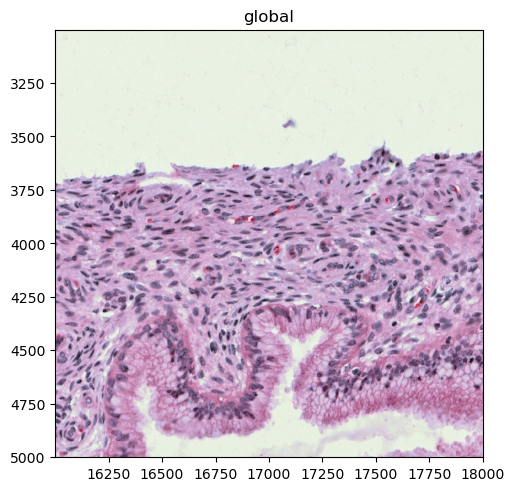

In [52]:
(
    cropped
    .pl.render_images("he_image")
    .pl.show()
)

In [ ]:
%load_ext watermark
%watermark -v -m -p spatialdata,spatialdata_io,spatialdata_plot,squidpy,scanpy,anndata,zarr,matplotlib,pandas,numpy

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_io  : 0.7.0
spatialdata_plot: 0.3.4
squidpy         : 1.8.1
scanpy          : 1.12.1
anndata         : 0.12.14
zarr            : 3.2.1
matplotlib      : 3.10.9
pandas          : 2.3.3
numpy           : 2.4.5

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.14.0-570.25.1.el9_6.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

